In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import photon_number
import snspd4

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260411-12624-qcodes.log
Experiment loaded. Last ID no: 457


# Parameters

In [2]:
params = snspd4.snspd4()

# Analysis

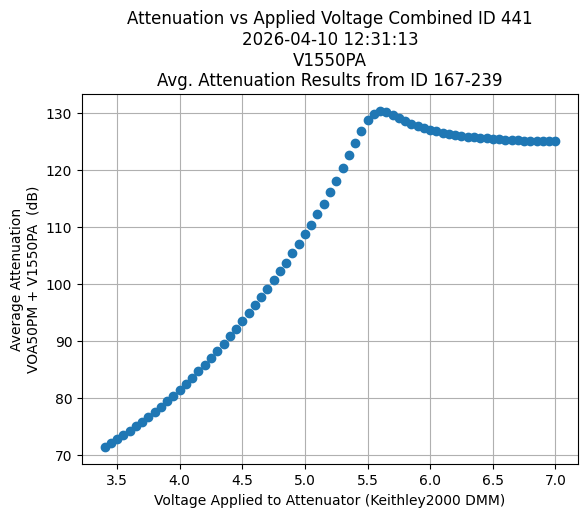

In [3]:
ID =  params.att_screw_calibration_id
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
att_name = load_by_id(ID).metadata['attenuator_name']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage Combined'
conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, avg_attenuation+avg_attenuation_screw, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley2000 DMM)')
plt.ylabel(f'Average Attenuation\n{params.att_screw_name} + {params.att_blue_name}  (dB)')
plt.grid()

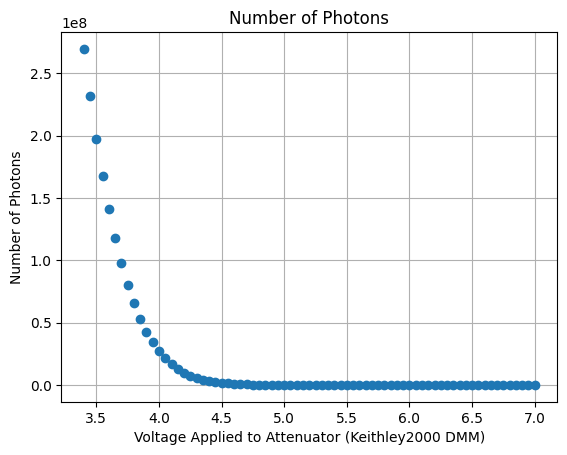

In [10]:
ID =  params.att_screw_calibration_id
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
avg_power90 = data['avg_power90']['avg_power90']

total_attenuation=avg_attenuation + avg_attenuation_screw

Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=1550e-9)

att_info = {}
for i in range(len(v_attenuator)): 
    att_info[f'{v_attenuator[i]}'] = {'total_attenuation': total_attenuation[i], 'Nphotons': Nphotons[i]}

plt.plot(v_attenuator, Nphotons, 'o')
plt.title(f'Number of Photons')
plt.ylabel('Number of Photons')
plt.xlabel('Voltage Applied to Attenuator (Keithley2000 DMM)')
plt.grid()

In [11]:
# meas = Measurement()
# meas.register_custom_parameter("v_attenuator", label="V")
# meas.register_custom_parameter("total_attenuation", label="dB")
# meas.register_custom_parameter("Nphotons", label="")

# with meas.run() as datasaver: 
#     print(datasaver.run_id)

#     ID =  params.att_screw_calibration_id
#     datasaver.dataset.add_metadata("att_screw_calibration_id", ID)
#     data = load_by_id(ID).get_parameter_data()
#     avg_attenuation_screw = np.average(data['attenuation']['attenuation'])
    
#     ID = params.att_blue_calibration_avg_id
#     datasaver.dataset.add_metadata("att_combined_id", ID)
#     data = load_by_id(ID).get_parameter_data()
#     # Extract attenuator voltages 
#     v_attenuator = data['v_attenuator']['v_attenuator']
#     avg_attenuation = data['avg_attenuation']['avg_attenuation']
#     avg_power90 = data['avg_power90']['avg_power90']
    
#     total_attenuation=avg_attenuation + avg_attenuation_screw
    
#     Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=1550e-9)
    

#     for i in range(len(v_attenuator)): 
#         datasaver.add_result(("v_attenuator", v_attenuator[i]),
#                          ("total_attenuation", total_attenuation[i]),
#                         ("Nphotons", Nphotons[i]))

Starting experimental run with id: 457. 
457


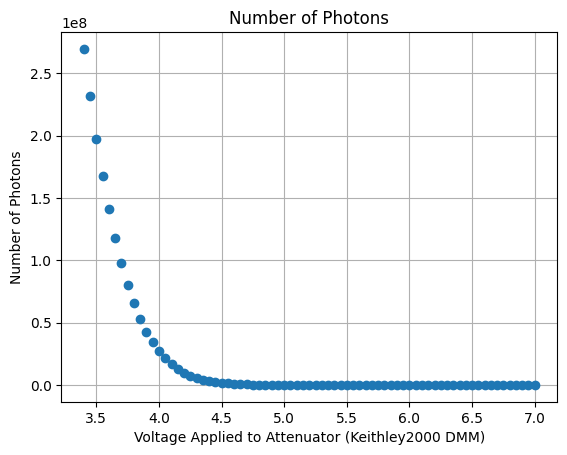

In [4]:
ID = params.att_info
data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
Nphotons = data['Nphotons']['Nphotons']
plt.plot(v_attenuator, Nphotons, 'o')
plt.title(f'Number of Photons')
plt.ylabel('Number of Photons')
plt.xlabel('Voltage Applied to Attenuator (Keithley2000 DMM)')
plt.grid()